In [1]:
#Bài 1
import folium
ueh_coords = [10.7828, 106.6959]
m = folium.Map(location=ueh_coords, zoom_start=16)
folium.Marker(
    location=ueh_coords,
    popup="Đại học Kinh tế TP.HCM (UEH)",
    icon=folium.Icon(color="red", icon="university", prefix="fa")).add_to(m)
places = [
    {"name": "Bệnh viện Quận 3", "coords": [10.7815, 106.6945]},
    {"name": "Công viên Lê Văn Tám", "coords": [10.7850, 106.6970]},
    {"name": "Nhà thờ Đức Bà", "coords": [10.7797, 106.6990]},
    {"name": "Diamond Plaza", "coords": [10.7805, 106.6985]},
    {"name": "Trạm xe buýt", "coords": [10.7835, 106.6940]}]
for place in places:
    folium.Marker(
        location=place["coords"],
        popup=place["name"],
        icon=folium.Icon(color="blue", icon="info-sign")).add_to(m)
m

In [2]:
#Bài 2
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

geolocator = Nominatim(user_agent="distance")
center_address = "UEH"

location_center = geolocator.geocode(center_address)

lat_root, lon_root = location_center.latitude, location_center.longitude

addresses = [
    "Dinh Độc Lập",
    "Chợ Bến Thành, Quận 1",
    "Bưu điện Trung tâm Sài Gòn",
    "Landmark 81, Bình Thạnh",
    "Hồ Con Rùa",
    "Đầm Sen",
    "Bưu điện Trung tâm TP.HCM"
]
m2 = folium.Map(location=[lat_root, lon_root], zoom_start=14)
folium.Marker([lat_root, lon_root], popup="GỐC", icon=folium.Icon(color='red')).add_to(m2)
for addr in addresses:
    loc = geolocator.geocode(addr)
    current_coords = (loc.latitude, loc.longitude)
    dist = geodesic((lat_root, lon_root), current_coords).km
    folium.Marker(
            location=[loc.latitude, loc.longitude],
            popup=f"{addr}: {dist:.2f} km").add_to(m2)
m2

In [ ]:
#Bài 3
import folium
from folium.plugins import HeatMap
import numpy as np
base_lat, base_lon = 10.7769, 106.7009
data = (np.random.normal(size=(100, 2)) * 0.02 + [base_lat, base_lon]).tolist()
m = folium.Map(location=[base_lat, base_lon], zoom_start=13)
HeatMap(data).add_to(m)
m

Cột trong GeoDataFrame: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']
Cột trong population DataFrame: ['year', 'ISO3', 'ADM0_EN', 'ADM0_PCODE', 'ADM1_EN', 'ADM1_VI', 'ADM1_PCODE', 'F_TL', 'M_TL', 'T_TL', 'F_00_04', 'F_05_09', 'F_10_14', 'F_15_19', 'F_20_24', 'F_25_29', 'F_30_34', 'F_35_39', 'F_40_44', 'F_45_49', 'F_50_54', 'F_55_59', 'F_60_64', 'F_65_69', 'F_70_74', 'F_75_79', 'F_80Plus', 'M_00_04', 'M_05_09', 'M_10_14', 'M_15_19', 'M_20_24', 'M_25_29', 'M_30_34', 'M_35_39', 'M_40_44', 'M_45_49', 'M_50_54', 'M_55_59', 'M_60_64', 'M_65_69', 'M_70_74', 'M_75_79', 'M_80Plus', 'T_00_04', 'T_05_09', 'T_10_14', 'T_15_19', 'T_20_24', 'T_25_29', 'T_30_34', 'T_35_39', 'T_40_44', 'T_45_49', 'T_50_54', 'T_55_59', 'T_60_64', 'T_65_69', 'T_70_74', 'T_75_79', 'T_80Plus']


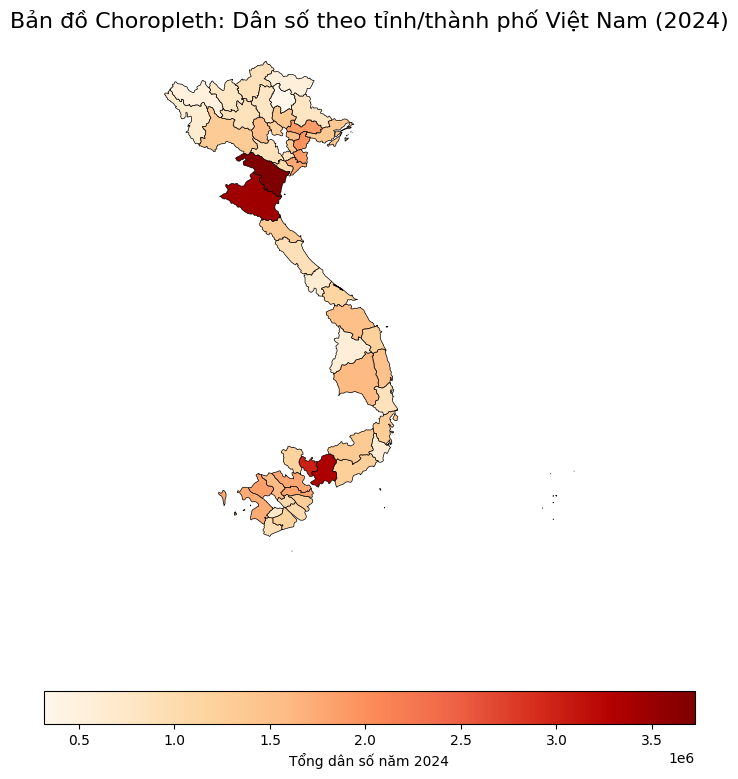

In [4]:
#Bài 4
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

url_geo = "https://data.humdata.org/dataset/geoboundaries-admin-boundaries-for-viet-nam/resource/f5addec1-ac25-4748-973b-377935593fee/download/geoboundaries-vnm-adm1.geojson"
gdf = gpd.read_file(url_geo)

print("Cột trong GeoDataFrame:", gdf.columns.tolist())
pop = pd.read_csv("vnm_admpop_adm1_2024.csv")
print("Cột trong population DataFrame:", pop.columns.tolist())
gdf = gdf.merge(pop, left_on='shapeName', right_on='ADM1_VI', how='left')
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
gdf.plot(column='T_TL'
         ax=ax,
         legend=True,
         cmap='OrRd',          # Màu đỏ-cam tăng dần theo dân số
         edgecolor='black',
         linewidth=0.5,
         legend_kwds={'label': "Tổng dân số năm 2024",
                      'orientation': "horizontal",
                      'shrink': 0.6})

ax.set_title("Bản đồ Choropleth: Dân số theo tỉnh/thành phố Việt Nam (2024)", fontsize=16)
ax.axis('off')
plt.show()

In [5]:
#Bài 5
import folium
from geopy.distance import geodesic
import pandas as pd

center_point = (10.7769, 106.7009)
df = pd.DataFrame({
    'ID': ['A', 'B', 'C', 'D', 'E'],
    'Lat': [10.785, 10.800, 10.750, 10.820, 10.700],
    'Lon': [106.710, 106.730, 106.680, 106.750, 106.650]})
m = folium.Map(location=center_point, zoom_start=12)

folium.Circle(center_point, radius=10000, color='red', fill=True, fill_opacity=0.1).add_to(m)
folium.Circle(center_point, radius=5000, color='orange', fill=True, fill_opacity=0.2).add_to(m)
folium.Circle(center_point, radius=3000, color='green', fill=True, fill_opacity=0.3).add_to(m)

data_array = df[['ID', 'Lat', 'Lon']].values

for row in data_array:
    cust_id = row[0]
    lat = row[1]
    lon = row[2]
    dist = geodesic(center_point, (lat, lon)).km
    color = 'gray'
    if dist <= 3: color = 'green'
    elif dist <= 10: color = 'blue'
    folium.Marker(
        location=[lat, lon],
        popup=f"ID: {cust_id} - {dist:.1f}km",
        icon=folium.Icon(color=color)).add_to(m)
folium.Marker(center_point, icon=folium.Icon(color='black', icon='star')).add_to(m)
m

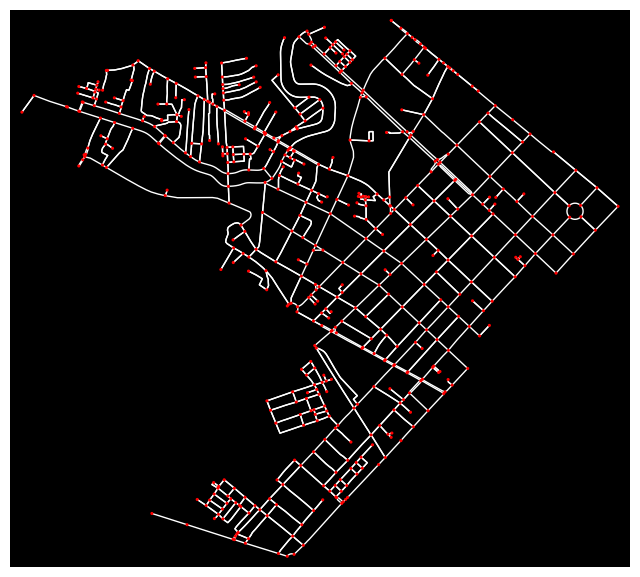

Số lượng nút giao (Nodes): 551
Số lượng đoạn đường (Edges): 1207
Chiều dài đường trung bình: 88.54 mét
Tổng chiều dài mạng lưới: 106.87 km
Mật độ nút giao: N/A nút/km2


In [19]:
#Bài 6
import osmnx as ox
import matplotlib.pyplot as plt
place_name = "District 3, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
fig, ax = ox.plot_graph(G, node_size=5, node_color='red', edge_color='white', bgcolor='black')
stats = ox.basic_stats(G)
print(f"Số lượng nút giao (Nodes): {stats['n']}")
print(f"Số lượng đoạn đường (Edges): {stats['m']}")
print(f"Chiều dài đường trung bình: {stats['edge_length_avg']:.2f} mét")
print(f"Tổng chiều dài mạng lưới: {stats['edge_length_total'] / 1000:.2f} km")
node_density_km_value = stats.get('node_density_km', 'N/A')
if node_density_km_value != 'N/A':
    print(f"Mật độ nút giao: {node_density_km_value:.2f} nút/km2")
else:
    print(f"Mật độ nút giao: {node_density_km_value} nút/km2")

Quãng đường Dijkstra: 310.83 mét
Quãng đường A*:       310.83 mét


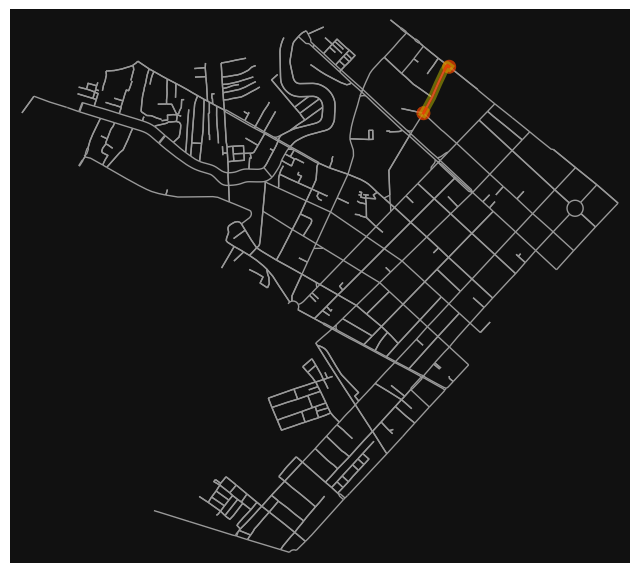

In [26]:
#Bài 7
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
place_name = "District 3, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
G_projected = ox.project_graph(G)
nodes = list(G_projected.nodes())
orig_node = nodes[0]
dest_node = nodes[-1]
route_dijkstra = nx.shortest_path(G_projected, source=orig_node, target=dest_node, weight='length', method='dijkstra')
def dist(u, v):
    x1, y1 = G_projected.nodes[u]['x'], G_projected.nodes[u]['y']
    x2, y2 = G_projected.nodes[v]['x'], G_projected.nodes[v]['y']
    return ((x1 - x2)**2 + (y1 - y2)**2)**0.5
route_astar = nx.astar_path(G_projected, source=orig_node, target=dest_node, heuristic=dist, weight='length')
def get_route_length(graph, route):
    return sum(ox.routing.route_to_gdf(graph, route)['length'])
len_dijkstra = get_route_length(G_projected, route_dijkstra)
len_astar = get_route_length(G_projected, route_astar)
print(f"Quãng đường Dijkstra: {len_dijkstra:.2f} mét")
print(f"Quãng đường A*:       {len_astar:.2f} mét")
fig, ax = ox.plot_graph_route(G_projected, route_dijkstra, route_color='y', route_linewidth=6, node_size=0, show=False, close=False)
ox.plot_graph_route(G_projected, route_astar, route_color='r', route_linewidth=2, node_size=0, ax=ax)
plt.show()

In [28]:
#Bài 8
import osmnx as ox
import folium
import random
import numpy as np

location = (10.7769, 106.7009)
G = ox.graph_from_point(location, dist=1000, network_type='drive')
G_projected = ox.project_graph(G)
nodes = list(G_projected.nodes())
customer_node = random.choice(nodes)
driver_nodes = random.sample(nodes, 3)
best_driver_node = None
min_dist = float('inf')
best_route = None

for d_node in driver_nodes:
    try:
        route = ox.shortest_path(G_projected, d_node, customer_node, weight='length')
        route_length = sum(ox.routing.route_to_gdf(G_projected, route)['length'])
        if route_length < min_dist:
            min_dist = route_length
            best_driver_node = d_node
            best_route = route
    except:
        continue
m = folium.Map(location=location, zoom_start=16)
c_lat, c_lon = G.nodes[customer_node]['y'], G.nodes[customer_node]['x']
folium.Marker([c_lat, c_lon], popup="Khách hàng", icon=folium.Icon(color='blue', icon='user')).add_to(m)
for d_node in driver_nodes:
    d_lat, d_lon = G.nodes[d_node]['y'], G.nodes[d_node]['x']
    color = 'green' if d_node == best_driver_node else 'red'
    status = "Tài xế được chọn" if d_node == best_driver_node else "Tài xế rảnh"
    folium.Marker([d_lat, d_lon], popup=status, icon=folium.Icon(color=color, icon='car')).add_to(m)
if best_route:
    route_gdf = ox.routing.route_to_gdf(G_projected, best_route)
    folium.GeoJson(route_gdf).add_to(m)
print(f"Khoảng cách đón khách gần nhất: {min_dist:.2f} mét")
m

Khoảng cách đón khách gần nhất: 1129.54 mét


In [30]:
#Bài 9
import pandas as pd
import folium
from sklearn.cluster import KMeans
data = {
    "Customer": ["KH1","KH2","KH3","KH4","KH5","KH6","KH7","KH8"],
    "Lat":[10.7769,10.7820,10.7600,10.7700,10.7550,10.8000,10.8100,10.7400],
    "Lon":[106.7009,106.6950,106.6800,106.7100,106.6750,106.7200,106.7300,106.6600]}
df = pd.DataFrame(data)
df
k = 3
kmeans = KMeans(n_clusters=k, random_state=0)
df["Cluster"] = kmeans.fit_predict(df[["Lat","Lon"]])
centroids = kmeans.cluster_centers_
df
map_center = [df["Lat"].mean(), df["Lon"].mean()]
m = folium.Map(location=map_center, zoom_start=12)
colors = ["red","blue","green","purple","orange"]
for i, row in df.iterrows():
    folium.CircleMarker(
        location=[row["Lat"], row["Lon"]],
        radius=6,
        color=colors[row["Cluster"]],
        fill=True,
        fill_color=colors[row["Cluster"]],
        popup=row["Customer"]).add_to(m)
for i, c in enumerate(centroids):
    folium.Marker(
        location=[c[0], c[1]],
        icon=folium.Icon(color="black", icon="home"),
        popup=f"Warehouse {i+1}").add_to(m)
m

In [32]:
#Bài 10
import folium
from folium.plugins import HeatMap
center = [10.7715, 106.6925]
m = folium.Map(location=center, zoom_start=15)
congestion_data = [
    [10.7715, 106.6925, 0.9],
    [10.7745, 106.6945, 0.7],
    [10.7700, 106.6910, 0.8],
    [10.7730, 106.7000, 0.6]]

HeatMap(congestion_data, radius=25, blur=15).add_to(m)
route_coords = [
    [10.7680, 106.6900],
    [10.7685, 106.6950],
    [10.7750, 106.7050]]

folium.PolyLine(route_coords, color='green', weight=5, opacity=0.8,
                tooltip="Tuyến đường đề xuất tránh tắc nghẽn").add_to(m)
folium.Marker(route_coords[0], popup="Điểm đi", icon=folium.Icon(color='blue')).add_to(m)
folium.Marker(route_coords[-1], popup="Điểm đến", icon=folium.Icon(color='green')).add_to(m)

m

In [35]:
#Bài 11
import folium
from sklearn.linear_model import LinearRegression
import numpy as np
hubs = {
    'Bitexco': [10.7715, 106.7042],
    'Ben Thanh': [10.7725, 106.6980],
    'Landmark 81': [10.7950, 106.7218]}
hours = np.array([8, 11, 14, 17, 20]).reshape(-1, 1)
radius_data = np.array([800, 400, 300, 1000, 600])
model = LinearRegression().fit(hours, radius_data)
predict_hour = 17
predicted_radius = model.predict([[predict_hour]])[0]
m = folium.Map(location=[10.78, 106.70], zoom_start=14)
for name, coords in hubs.items():
    folium.Marker(coords, popup=name).add_to(m)
    folium.Circle(
        location=coords,
        radius=predicted_radius,
        color='red',
        fill=True,
        fill_opacity=0.3,
        tooltip=f"Nhu cầu dự báo lúc {predict_hour}h: Bán kính {predicted_radius:.0f}m").add_to(m)
m

In [41]:
#Bài 12
import folium
depots = {
    'Kho A (Bến Thành)': [10.7725, 106.6980],
    'Kho B (Hồ Con Rùa)': [10.7827, 106.6958]}
points = [
    [10.7750, 106.7010], [10.7710, 106.6950], [10.7800, 106.6930],
    [10.7850, 106.6980], [10.7780, 106.6970], [10.7700, 106.7050]]

m = folium.Map(location=[10.7770, 106.6970], zoom_start=15)
colors = {'Kho A (Bến Thành)': 'blue', 'Kho B (Hồ Con Rùa)': 'red'}
for name, coords in depots.items():
    folium.Marker(coords, popup=name, icon=folium.Icon(color='black', icon='warehouse', prefix='fa')).add_to(m)
    folium.Circle(
        location=coords,
        radius=600,
        color=colors[name],
        fill=True,
        fill_opacity=0.2,
        tooltip=f"Khu vực ưu tiên của {name}").add_to(m)
for p in points:
    folium.CircleMarker(p, radius=5, color='green', fill=True).add_to(m)
m

In [42]:
#Bài 13
import folium
from folium.plugins import HeatMap, MarkerCluster
import numpy as np
m = folium.Map(location=[10.7760, 106.7000], zoom_start=13)

layer_zones = folium.FeatureGroup(name='Vùng Phủ Sóng')
depots = [[10.7725, 106.6980], [10.7827, 106.6958]] # Bến Thành & Hồ Con Rùa

for i, d in enumerate(depots):
    folium.Circle(
        location=d, radius=500, color='blue', fill=True, fill_opacity=0.2,
        popup=f"Vùng phục vụ Kho {i+1}").add_to(layer_zones)
layer_zones.add_to(m)
layer_routes = folium.FeatureGroup(name='Lộ Trình Giao Hàng Tối Ưu')
path_1 = [[10.7725, 106.6980], [10.7750, 106.7010], [10.7800, 106.7050]]
path_2 = [[10.7827, 106.6958], [10.7850, 106.6900], [10.7700, 106.6850]]

folium.PolyLine(path_1, color='green', weight=5, opacity=0.8, tooltip="Tuyến 01").add_to(layer_routes)
folium.PolyLine(path_2, color='darkred', weight=5, opacity=0.8, tooltip="Tuyến 02").add_to(layer_routes)
layer_routes.add_to(m)

layer_points = folium.FeatureGroup(name='Vị Trí Đơn Hàng')
marker_cluster = MarkerCluster().add_to(layer_points)
np.random.seed(42)
for _ in range(50):
    lat = np.random.uniform(10.765, 10.790)
    lon = np.random.uniform(106.685, 106.710)
    folium.Marker([lat, lon], icon=folium.Icon(color='orange', icon='info-sign')).add_to(marker_cluster)
layer_points.add_to(m)
layer_heat = folium.FeatureGroup(name='Mật Độ Nhu Cầu (Heatmap)', show=False)
heat_data = [[np.random.uniform(10.765, 10.790), np.random.uniform(106.685, 106.710), 1] for _ in range(100)]
HeatMap(heat_data).add_to(layer_heat)
layer_heat.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m

In [44]:
#Bài 14
import osmnx as ox
import networkx as nx
import folium

location = [10.7769, 106.7009]
G = ox.graph_from_point(location, dist=800, network_type='drive')
G_projected = ox.project_graph(G)
nodes = list(G_projected.nodes())
orig, dest = nodes[0], nodes[-1]
route = nx.shortest_path(G_projected, orig, dest, weight='length')
route_coords = [[G.nodes[node]['y'], G.nodes[node]['x']] for node in route]
m = folium.Map(location=location, zoom_start=16)
folium.PolyLine(route_coords, color='gray', weight=3, opacity=0.5, tooltip="Lộ trình dự kiến").add_to(m)
steps = [0, 0.25, 0.5, 0.75, 1.0]
for i, progress in enumerate(steps):
    idx = int(progress * (len(route_coords) - 1))
    pos = route_coords[idx]
    icon_color = 'orange'
    status_text = f"T{i+1}: Đang di chuyển ({int(progress*100)}%)"
    if progress == 0:
        icon_color = 'blue'
        status_text = "T1: Xuất phát"
    elif progress == 1.0:
        icon_color = 'green'
        status_text = "T5: Đã hoàn thành"
    folium.Marker(
        location=pos,
        popup=status_text,
        tooltip=f"Thời điểm T{i+1}",
        icon=folium.Icon(color=icon_color, icon='car', prefix='fa')).add_to(m)
    folium.PolyLine(route_coords[:idx+1], color='blue', weight=5, opacity=0.8).add_to(m)
m

In [46]:
#Bài 15
import folium
from folium.plugins import HeatMap
import numpy as np

center = [10.7769, 106.7009]
m = folium.Map(location=center, zoom_start=15)
our_stores = [[10.7725, 106.6980], [10.7827, 106.6958]]
for store in our_stores:
    folium.Marker(store, popup="Cửa hàng hiện tại",
                  icon=folium.Icon(color='blue', icon='shop', prefix='fa')).add_to(m)
competitors = [[10.7750, 106.7010], [10.7710, 106.6950], [10.7800, 106.7050]]
for comp in competitors:
    folium.Marker(comp, popup="Đối thủ",
                  icon=folium.Icon(color='red', icon='fire', prefix='fa')).add_to(m)
demand_data = [
    [10.7780, 106.6970, 0.9], [10.7790, 106.6990, 0.8],
    [10.7740, 106.7030, 0.7], [10.7850, 106.6920, 0.9]]
HeatMap(demand_data, name="Mật độ nhu cầu tiềm năng").add_to(m)
ai_suggestion = [10.7785, 106.6975]
folium.Marker(
    ai_suggestion,
    popup="VỊ TRÍ AI ĐỀ XUẤT MỞ MỚI",
    icon=folium.Icon(color='green', icon='star', prefix='fa')).add_to(m)
folium.Circle(ai_suggestion, radius=500, color='green', fill=True, fill_opacity=0.1).add_to(m)
folium.LayerControl().add_to(m)
m